# Automatic differentiation from scratch (instructor version)

PT01 uses `backward()`; PT02 uses it to train a classifier. Here we build a small
NumPy engine that does the differentiation itself. We then compare it with
PyTorch on the same classifier, including the bias update.

Complete three activities in order: local backward rules, a backward pass over
the graph, and one classifier update. The wrapper, plotting, data and stable
loss are provided. Optional exercises follow the training comparison.

You need PT01's tensor and autograd basics and PT02's batched linear classifier.
This notebook runs independently of those files. Its title has no lecture
number because the CNN/autodiff teaching order is still open.

This instructor version includes executable solutions in cells tagged
`reference`. The generated student version removes them and all saved outputs.
An unfinished activity raises an error; it never silently calls a solution.

> [!note] Written by Codex (2026-10-07)
> Adapted from Simone Scardapane's autodiff Colab pair and the shared PT01/PT02
> notebooks. See the sources at the end.

## 1. Setup and the backward quantities

The existing PT01/PT02 dependencies are enough. All comparisons run on CPU in
float64 so numerical rounding is easier to separate from implementation errors.

In [1]:
from pathlib import Path
from urllib.request import urlopen
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import torch
import torch.nn.functional as F
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(7)
np.set_printoptions(precision=4, suppress=True)
torch.set_num_threads(1)
print('NumPy', np.__version__, '| PyTorch', torch.__version__)

def close(actual, expected, *, atol=1e-9, rtol=1e-9):
    actual, expected = np.asarray(actual), np.asarray(expected)
    assert actual.shape == expected.shape, (actual.shape, expected.shape)
    np.testing.assert_allclose(actual, expected, atol=atol, rtol=rtol)

def expect_error(kind, function):
    try:
        function()
    except kind:
        return
    raise AssertionError(f'Expected {kind.__name__}')

NumPy 2.5.3 | PyTorch 2.14.1


For $y=f(x)$, the derivative $Df(x)$ maps an input perturbation $h$ to an
output perturbation. This is the slides' $\partial f(x)[h]$, or JVP.

A **cotangent** describes a linear sensitivity to a perturbation. In this lab,
we represent it by an array $\bar y$ with the shape of $y$, using the standard
Euclidean inner product (vectors) or Frobenius inner product (matrices).
Thus a downstream scalar objective has differential
$dL=\langle\bar y,dy\rangle$. Cotangents are formally covectors; this
inner-product identification is why we can store them as ordinary arrays.

The **pullback at $x$** maps the output sensitivity to the input sensitivity:

$$\bar x=Df(x)^*[\bar y],\qquad
\langle\bar y,Df(x)[h]\rangle=\langle\bar x,h\rangle.$$

It is exactly the slides' adjoint derivative / VJP map
$\partial f(x)^*$. These names describe the same backward computation under
our chosen inner products. For a scalar loss, seed $\bar L=1$ and the resulting
input cotangent is the ordinary gradient. For a vector output, a fixed seed $v$
gives $\nabla_x\langle v,f(x)\rangle$, not a full Jacobian.

For an operation with two inputs, the pullback returns two cotangents, one per
input **position**. If both positions use the same node, both contributions
must be added. Predict the shapes for $W\in\mathbb R^{3\times4}$,
$x\in\mathbb R^4$ and $y=Wx$: what are the shapes of $\bar y,\bar W,\bar x$?

Instructor answer: $\bar y$ has shape $(3,)$, $\bar W$ has shape $(3,4)$,
and $\bar x$ has shape $(4,)$. The weight pullback is $\bar yx^\top$.

## 2. Values and their computation graph

Each `Tensor` stores a value, its input nodes and a local pullback. Its value is
an immutable copy: changing a parameter means constructing a new leaf and a new
forward graph. This keeps the saved forward values consistent with backward.

The wrapper below is supplied. Read `__add__` and `__mul__`: their forward
computations already work, and their closures will use your Activity 1 rules.
We differentiate every reachable floating-point node, including constants.
There is no `requires_grad` flag or persistent `.grad` buffer in this small engine.

In [2]:
class Tensor:
    def __init__(self, value, parents=(), pullback=None, name='leaf'):
        self.value = np.array(value, dtype=np.float64, copy=True)
        self.value.setflags(write=False)
        self.parents = tuple(parents)  # Preserve repeated operand positions.
        self.pullback = pullback
        self.name = name

    def __repr__(self):
        return f'Tensor({self.name}, shape={self.value.shape}, value={self.value})'

    def __add__(self, other):
        other = as_tensor(other)
        return Tensor(self.value + other.value, (self, other),
                      lambda v: add_pullback(self.value, other.value, v), '+')

    __radd__ = __add__

    def __mul__(self, other):
        other = as_tensor(other)
        return Tensor(self.value * other.value, (self, other),
                      lambda v: multiply_pullback(self.value, other.value, v), '*')

    __rmul__ = __mul__

    def __matmul__(self, other):
        other = as_tensor(other)
        if self.value.ndim not in (1, 2) or other.value.ndim not in (1, 2):
            raise ValueError('matmul supports vectors and matrices only')
        return Tensor(self.value @ other.value, (self, other),
                      lambda v: matmul_pullback(self.value, other.value, v), '@')

    @property
    def T(self):
        if self.value.ndim not in (1, 2):
            raise ValueError('transpose supports vectors and matrices only')
        return Tensor(self.value.T, (self,), lambda v: (v.T,), 'transpose')

    def sum(self, axis=None, keepdims=False):
        ndim = self.value.ndim
        axes = tuple(range(ndim)) if axis is None else ((axis,) if isinstance(axis, int) else tuple(axis))
        if any(not isinstance(a, int) or not -ndim <= a < ndim for a in axes):
            raise ValueError('Invalid reduction axis')
        axes = tuple(sorted(a % ndim for a in axes))
        if len(set(axes)) != len(axes):
            raise ValueError('Repeated reduction axis')
        value = self.value.sum(axis=axes, keepdims=keepdims)
        def pullback(v):
            expanded = v
            if not keepdims:
                for a in axes:
                    expanded = np.expand_dims(expanded, a)
            return (np.broadcast_to(expanded, self.value.shape).copy(),)
        return Tensor(value, (self,), pullback, 'sum')

def as_tensor(value):
    return value if isinstance(value, Tensor) else Tensor(value, name='constant')

Graph nodes have identity, not just a name or a value. In `u + u`, the two input
positions refer to one node. The supplied visualizer draws that node once and
draws both incoming edges. It uses Matplotlib, without Graphviz or system installs.

For the next example, predict how many nodes exist before running the cell.

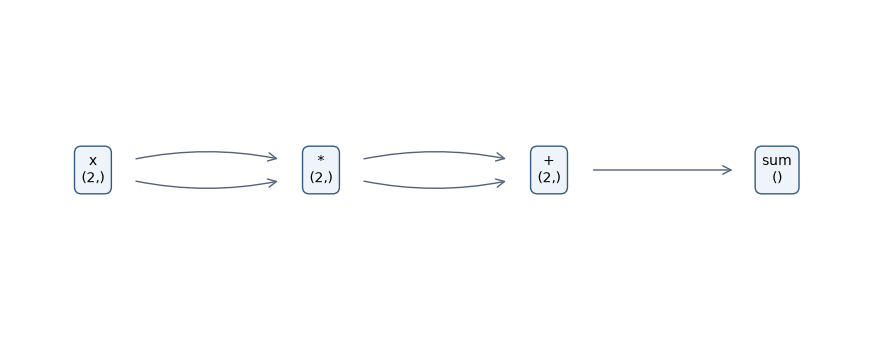

In [3]:
def graph_nodes(output):
    # This helper collects nodes for drawing only. Its order is not a backward schedule.
    nodes, seen, pending = [], set(), [output]
    while pending:
        node = pending.pop()
        if node in seen:
            continue
        seen.add(node)
        nodes.append(node)
        pending.extend(reversed(node.parents))
    return nodes

def draw_graph(output):
    nodes = graph_nodes(output)
    remaining, depth = set(nodes), {}
    while remaining:
        ready = [n for n in nodes if n in remaining and all(p in depth for p in n.parents)]
        if not ready:
            raise ValueError('The graph must be acyclic')
        for node in ready:
            depth[node] = 0 if not node.parents else 1 + max(depth[p] for p in node.parents)
            remaining.remove(node)
    positions = {}
    for level in sorted(set(depth.values())):
        group = [n for n in reversed(nodes) if depth[n] == level]
        for i, node in enumerate(group):
            positions[node] = (level * 2.2, i - (len(group) - 1) / 2)
    fig, ax = plt.subplots(figsize=(max(7, 2.2 * (max(depth.values()) + 1)), 3.5))
    for node in nodes:
        for slot, parent in enumerate(node.parents):
            repeated = sum(p is parent for p in node.parents) > 1
            radius = (0.16 if slot == 0 else -0.16) if repeated else 0
            arrow = FancyArrowPatch(positions[parent], positions[node], arrowstyle='->',
                                    mutation_scale=15, shrinkA=32, shrinkB=32,
                                    connectionstyle=f'arc3,rad={radius}', color='#526378')
            ax.add_patch(arrow)
    for node, (x, y) in positions.items():
        ax.text(x, y, f'{node.name}\n{node.value.shape}', ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.5', fc='#eef4fa', ec='#365b80'))
    ax.set_xlim(-0.8, max(x for x, y in positions.values()) + 0.8)
    ax.set_ylim(min(y for x, y in positions.values()) - 0.8,
                max(y for x, y in positions.values()) + 0.8)
    ax.axis('off')
    fig.tight_layout()
    return fig

graph_x = Tensor([1., 2.], name='x')
graph_u = graph_x * graph_x
graph_loss = (graph_u + graph_u).sum()
assert len(graph_nodes(graph_loss)) == 4
draw_graph(graph_loss)
plt.show()

## 3. Activity 1: local pullbacks

Implement the four functions below. `v` is the output cotangent. Return a tuple
with one array per input position; each array must have that input's exact shape.

**Broadcasting.** If a vector of shape $(C,)$ is added to a batch of shape $(B,C)$,
each vector entry is reused $B$ times. Its backward contributions must be summed
over the batch axis. `sum_to_shape` reverses this reuse: remove extra leading
axes by summation, then sum expanded singleton axes while keeping their dimensions.
For a scalar input, sum all entries. This matters even when $B=C$ and the wrong
axis would produce the same shape.

**Addition and multiplication.** For $z=a+b$, each input receives $v$, reduced
to its shape. For $z=a\odot b$, the unreduced contributions are $v\odot b$ and
$v\odot a$.

**Matrix products.** For $z=AB$, use $\bar A=vB^\top$ and
$\bar B=A^\top v$. For $z=Ax$, use $\bar A=vx^\top$ and
$\bar x=A^\top v$. Handle vector-vector and vector-matrix products too.
Restrict the inputs to rank 1 or 2; arbitrary batched `matmul` is outside this lab.

Transpose and sum pullbacks are already supplied in `Tensor`. Read them and
explain why a sum broadcasts its seed back to the input shape.

In [4]:
def sum_to_shape(v, shape):
    raise NotImplementedError('Complete Activity 1: sum_to_shape')

def add_pullback(a, b, v):
    raise NotImplementedError('Complete Activity 1: addition')

def multiply_pullback(a, b, v):
    raise NotImplementedError('Complete Activity 1: multiplication')

def matmul_pullback(a, b, v):
    raise NotImplementedError('Complete Activity 1: matrix products')

### Instructor reference: local rules

The two vector promotions implicit in matrix multiplication need special care.
Writing the four rank combinations separately keeps their shapes visible.

In [5]:
def sum_to_shape(v, shape):
    v = np.asarray(v, dtype=np.float64)
    shape = tuple(shape)
    if len(shape) > v.ndim:
        raise ValueError('Target has more axes than the broadcasted output')
    while v.ndim > len(shape):
        v = v.sum(axis=0)
    for axis, size in enumerate(shape):
        if size == 1:
            v = v.sum(axis=axis, keepdims=True)
        elif size != v.shape[axis]:
            raise ValueError('Target is not a broadcast-compatible input shape')
    return v.reshape(shape).copy()

def add_pullback(a, b, v):
    return sum_to_shape(v, a.shape), sum_to_shape(v, b.shape)

def multiply_pullback(a, b, v):
    return sum_to_shape(v * b, a.shape), sum_to_shape(v * a, b.shape)

def matmul_pullback(a, b, v):
    if a.ndim == b.ndim == 1:
        return v * b, v * a
    if a.ndim == 2 and b.ndim == 1:
        return np.outer(v, b), a.T @ v
    if a.ndim == 1 and b.ndim == 2:
        return v @ b.T, np.outer(a, v)
    if a.ndim == b.ndim == 2:
        return v @ b.T, a.T @ v
    raise ValueError('matmul supports vectors and matrices only')

In [6]:
def check_local_rules():
    v = np.arange(1., 10.).reshape(3, 3)
    close(sum_to_shape(v, (3,)), np.array([12., 15., 18.]))
    close(sum_to_shape(v, ()), np.array(45.))
    close(sum_to_shape(np.ones((2, 3, 4)), (1, 3, 1)), np.full((1, 3, 1), 8.))
    close(sum_to_shape(np.ones((2, 3, 4)), (4,)), np.full(4, 6.))
    close(sum_to_shape(np.array(2.), ()), np.array(2.))
    close(sum_to_shape(v, (3, 3)), v)
    # Nonuniform values distinguish summing the wrong axis on a square batch.
    a, b = np.arange(9.).reshape(3, 3), np.array([2., 3., 5.])
    da, db = add_pullback(a, b, v)
    close(da, v)
    close(db, v.sum(axis=0))
    da, db = multiply_pullback(a, b, v)
    close(da, v * b)
    close(db, (v * a).sum(axis=0))
    local_rng = np.random.default_rng(11)
    for a_shape, b_shape in [((4,), (4,)), ((3, 4), (4,)),
                              ((4,), (4, 3)), ((2, 4), (4, 3)),
                              ((), (2, 3)), ((1, 3, 1), (2, 1, 4))]:
        a = local_rng.normal(size=a_shape)
        b = local_rng.normal(size=b_shape)
        operation = np.matmul if a.ndim in (1, 2) and b.ndim in (1, 2) else np.multiply
        rule = matmul_pullback if operation is np.matmul else multiply_pullback
        seed = local_rng.normal(size=np.asarray(operation(a, b)).shape)
        da, db = rule(a, b, seed)
        ta = torch.tensor(a, requires_grad=True)
        tb = torch.tensor(b, requires_grad=True)
        result = ta @ tb if operation is np.matmul else ta * tb
        (result * torch.tensor(seed)).sum().backward()
        close(da, ta.grad.numpy())
        close(db, tb.grad.numpy())
        ha, hb = local_rng.normal(size=a.shape), local_rng.normal(size=b.shape)
        eps = 1e-6
        finite_difference = ((operation(a + eps * ha, b + eps * hb) -
                              operation(a - eps * ha, b - eps * hb)) * seed).sum() / (2 * eps)
        close(np.array((da * ha).sum() + (db * hb).sum()),
              np.array(finite_difference), atol=1e-7, rtol=1e-7)
    print('Local rules: exact shapes, broadcasting, PyTorch and finite differences passed.')

check_local_rules()

Local rules: exact shapes, broadcasting, PyTorch and finite differences passed.


## 4. Activity 2: when is a node ready for backward?

A graph traversal is not automatically a valid differentiation schedule.
Consider a scalar $x=2$ and this graph:

$$u=x^2,\qquad a=3u,\qquad b=u^2,\qquad L=a+b.$$

After seeding $\bar L=1$, branch $a$ contributes $3$ to $\bar u$ and branch
$b$ contributes $2u=8$. The complete cotangent is therefore $\bar u=11$,
and $\bar x=2x\bar u=44$.

If we process $u$ after branch $a$ and mark it finished, we propagate only
$2x\cdot3=12$ to $x$. The later contribution from $b$ arrives too late.
Recursively propagating each contribution separately can give the right answer,
but revisits shared upstream work. Repeated sharing can make that work exponential.

A **topological order** lists every parent before its consumers. Reversing that
order puts every consumer before its parents, so all downstream contributions
have arrived when a node is processed. There can be several valid orders.
For the named nodes above, one is $x,u,a,b,L$, with backward order $L,b,a,u,x$.
The implementation graph also contains constant leaves for `3`.

Inspect the numeric trace below. Predict the final two rows before running it.

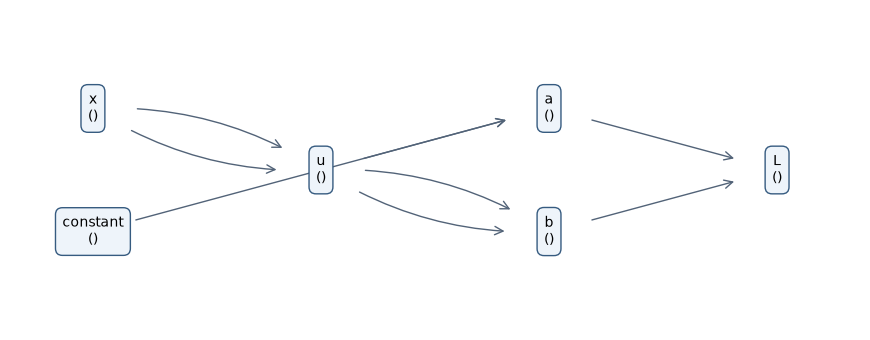

node  complete cotangent                    action
   L                 1.0                      seed
   a                 1.0        contributes 3 to u
   b                 1.0        contributes 8 to u
   u                11.0 ready after BOTH branches
   x                44.0            final gradient


In [7]:
order_x = Tensor(2., name='x')
order_u = order_x * order_x
order_u.name = 'u'
order_a = 3 * order_u
order_a.name = 'a'
order_b = order_u * order_u
order_b.name = 'b'
order_loss = order_a + order_b
order_loss.name = 'L'
draw_graph(order_loss)
plt.show()

u_value = order_u.value.item()
ordering_trace = pd.DataFrame([
    ['L', 1., 'seed'],
    ['a', 1., 'contributes 3 to u'],
    ['b', 1., f'contributes {2 * u_value:g} to u'],
    ['u', 3 + 2 * u_value, 'ready after BOTH branches'],
    ['x', 2 * order_x.value.item() * (3 + 2 * u_value), 'final gradient'],
], columns=['node', 'complete cotangent', 'action'])
print(ordering_trace.to_string(index=False))

Implement `topological_order(output)` and `backward(output, seed=None)`.

For ordering, use an explicit depth-first stack with a visited set and a
post-visit marker: append a node after all its parents. An iterative traversal
also works on chains longer than Python's recursion limit. Deduplicate **nodes**
in the traversal, but keep repeated **operand positions** in each pullback.

For backward:

1. Collect the reachable nodes in topological order.
2. Use seed `1` only for a scalar output (shape `()`). A nonscalar output needs
   an explicit seed with exactly the output shape, even if it contains one element.
3. Allocate a fresh zero cotangent for every node and set the output cotangent.
4. In reverse order, call each operation's pullback once. Add each contribution
   to its parent's cotangent; do not overwrite a contribution from another edge.
5. Return the dictionary mapping nodes to cotangents. Do not change their values.

The supplied `initial_cotangents` handles step 2 and allocation. Use it in your
implementation. This engine starts fresh on each call, whereas PyTorch usually
accumulates into leaf `.grad` buffers. Both implement the same derivative; their
buffer interfaces differ.

In [8]:
def initial_cotangents(nodes, output, seed):
    if seed is None:
        if output.value.shape != ():
            raise ValueError('A nonscalar output needs an explicit cotangent seed')
        seed = np.array(1.)
    seed = np.asarray(seed, dtype=np.float64)
    if seed.shape != output.value.shape:
        raise ValueError('Seed shape must equal output shape')
    cotangents = {node: np.zeros_like(node.value) for node in nodes}
    cotangents[output] = seed.copy()
    return cotangents

In [9]:
def topological_order(output):
    raise NotImplementedError('Complete Activity 2: topological ordering')

def backward(output, seed=None):
    raise NotImplementedError('Complete Activity 2: backward')

### Instructor reference: one reverse pass

Visited nodes are appended after their parents. Repeated parent entries still
produce two contributions in backward, which is necessary for `x * x`.

In [10]:
def topological_order(output):
    order, seen, pending = [], set(), [(output, False)]
    while pending:
        node, expanded = pending.pop()
        if expanded:
            order.append(node)
        elif node not in seen:
            seen.add(node)
            pending.append((node, True))
            pending.extend((parent, False) for parent in reversed(node.parents))
    return order

def backward(output, seed=None):
    nodes = topological_order(output)
    cotangents = initial_cotangents(nodes, output, seed)
    for node in reversed(nodes):
        if node.pullback is None:
            continue
        contributions = node.pullback(cotangents[node])
        if len(contributions) != len(node.parents):
            raise ValueError('One cotangent is required per input position')
        for parent, contribution in zip(node.parents, contributions):
            contribution = np.asarray(contribution, dtype=np.float64)
            if contribution.shape != parent.value.shape:
                raise ValueError('A pullback returned the wrong input shape')
            cotangents[parent] += contribution
    return cotangents

In [11]:
def check_backward():
    positions = {node: i for i, node in enumerate(topological_order(order_loss))}
    assert len(positions) == len(graph_nodes(order_loss))
    assert all(positions[parent] < positions[node]
               for node in positions for parent in node.parents)
    first = backward(order_loss)
    close(first[order_u], np.array(11.))
    close(first[order_x], np.array(44.))
    second = backward(order_loss)
    close(second[order_x], first[order_x])
    assert first[order_x] is not second[order_x]
    close(order_x.value, np.array(2.))

    x = Tensor([2., -3.])
    close(backward((x * x).sum())[x], np.array([4., -6.]))
    y = x * x + x
    close(backward(y, np.array([2., -1.]))[x], np.array([10., 5.]))
    expect_error(ValueError, lambda: backward(y))
    expect_error(ValueError, lambda: backward(y, 1.))
    expect_error(ValueError, lambda: backward(y, np.ones((2, 1))))
    expect_error(ValueError, lambda: backward(Tensor([1.])))
    # A leaf can itself be the output.
    leaf = Tensor(3.)
    close(backward(leaf)[leaf], np.array(1.))

    bias = Tensor([1., 2., 3.])
    z = Tensor(np.arange(9.).reshape(3, 3)) + bias
    seed = np.arange(1., 10.).reshape(3, 3)
    close(backward(z, seed)[bias], seed.sum(axis=0))
    m = Tensor(np.arange(6.).reshape(2, 3))
    close(backward(m.T, np.arange(6.).reshape(3, 2))[m], np.arange(6.).reshape(3, 2).T)
    cube = Tensor(np.ones((2, 3, 4)))
    close(backward(cube.sum(axis=(0, 2)), np.array([1., 2., 3.]))[cube],
          np.broadcast_to(np.array([1., 2., 3.])[None, :, None], (2, 3, 4)))
    close(backward(cube.sum(axis=1, keepdims=True), np.ones((2, 1, 4)))[cube], np.ones((2, 3, 4)))

    # Twelve shared additions have 13 nodes, not 4096 separate paths to process.
    leaf = Tensor(1.)
    repeated = leaf
    counts = {}
    for i in range(12):
        previous = repeated
        def counted(v, key=i):
            counts[key] = counts.get(key, 0) + 1
            return (v, v)
        repeated = Tensor(2 * previous.value, (previous, previous), counted, '+')
    close(backward(repeated)[leaf], np.array(4096.))
    assert counts == {i: 1 for i in range(12)}, counts
    assert len(topological_order(repeated)) == 13
    deep = Tensor(0.)
    for i in range(1500):
        deep = Tensor(deep.value + 1, (deep,), lambda v: (v,), 'increment')
    assert len(topological_order(deep)) == 1501
    backward(deep)
    print('Backward: shared nodes, seeds, reductions, fresh buffers and one visit per node passed.')

check_backward()

Backward: shared nodes, seeds, reductions, fresh buffers and one visit per node passed.


## 5. A classifier with supplied data and loss

Use PT02's model: $Z=XW^\top+b$, with $X$ shaped $(B,D)$, $W$ shaped $(C,D)$
and $b$ shaped $(C,)$. The bias is reused for every example, so its cotangent
must be summed over the batch axis.

The next cell supplies PT02's Penguins setup: four measurements, the same fixed
stratified split and scaling fitted on the training set only. The bundled CSV
supports offline execution. When opened alone in Colab, the notebook downloads
the source CSV and checks its hash. Data loading is not an exercise.

In [12]:
DATA_URL = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'
DATA_SHA256 = 'f204db2c753b0937caac3cb35258562c14f073e4bbc76be24b4c51ce22767a93'
data_path = Path('data/penguins.csv')
if data_path.exists():
    data_bytes = data_path.read_bytes()
else:
    data_bytes = urlopen(DATA_URL, timeout=30).read()
assert hashlib.sha256(data_bytes).hexdigest() == DATA_SHA256, 'Dataset changed; use the bundled CSV.'
from io import BytesIO
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
classes = ['Adelie', 'Chinstrap', 'Gentoo']
penguins = pd.read_csv(BytesIO(data_bytes)).dropna(subset=features + ['species'])
# Preserve PT02's float32 preprocessing, then promote those same values for parity checks.
raw_X = torch.tensor(penguins[features].to_numpy(), dtype=torch.float32)
all_y = pd.Categorical(penguins.species, categories=classes).codes.copy().astype(np.int64)
indices = np.arange(len(all_y))
train_idx, rest_idx = train_test_split(indices, test_size=0.4, stratify=all_y, random_state=7)
val_idx, test_idx = train_test_split(rest_idx, test_size=0.5, stratify=all_y[rest_idx], random_state=7)
mean = raw_X[train_idx].mean(dim=0)
scale = raw_X[train_idx].std(dim=0, correction=0).clamp_min(1e-8)
Xtrain, Xval, Xtest = [((raw_X[idx] - mean) / scale).double().numpy()
                          for idx in (train_idx, val_idx, test_idx)]
ytrain, yval, ytest = [all_y[idx] for idx in (train_idx, val_idx, test_idx)]
assert Xtrain.shape == (205, 4) and Xval.shape == (68, 4) and Xtest.shape == (69, 4)
assert not (set(train_idx) & set(val_idx) or set(train_idx) & set(test_idx) or set(val_idx) & set(test_idx))
print('Examples:', len(ytrain), 'training;', len(yval), 'validation;', len(ytest), 'test')

Examples: 205 training; 68 validation; 69 test


We supply mean cross-entropy as one primitive, including its pullback:

$$L(Z,y)=\frac1B\sum_i\left[\log\sum_c e^{Z_{ic}}-Z_{i,y_i}\right],
\qquad \bar Z=\bar L\,\frac{\operatorname{softmax}(Z)-Y}{B},$$

where $Y$ is the one-hot target matrix. Subtract the maximum logit in each row
before exponentiating. The implementation also subtracts the selected **shifted**
logit in the loss, avoiding cancellation from a large common offset.
The maximum is an algebraic device inside this supplied primitive, not a separate
node whose backward rule you need to implement.

Read the division by $B$: omitting it gives the summed-loss gradient and changes
the update. Targets are fixed integer labels; the primitive differentiates only
with respect to logits. PT02 already asks you to implement the loss, so here we
use it to test the engine.

In [13]:
def cross_entropy(logits, targets):
    logits = as_tensor(logits)
    targets = np.asarray(targets)
    if logits.value.ndim != 2 or logits.value.shape[0] == 0 or logits.value.shape[1] == 0:
        raise ValueError('Logits must be a nonempty (batch, classes) matrix')
    if targets.shape != (len(logits.value),) or not np.issubdtype(targets.dtype, np.integer):
        raise ValueError('Targets must be a batch of integer class indices')
    if (targets < 0).any() or (targets >= logits.value.shape[1]).any():
        raise ValueError('Target index out of range')
    shifted = logits.value - logits.value.max(axis=1, keepdims=True)
    exp = np.exp(shifted)
    normalizer = exp.sum(axis=1, keepdims=True)
    rows = np.arange(len(targets))
    value = (np.log(normalizer[:, 0]) - shifted[rows, targets]).mean()
    local_gradient = exp / normalizer
    local_gradient[rows, targets] -= 1
    local_gradient /= len(targets)
    return Tensor(value, (logits,), lambda v: (v * local_gradient,), 'mean cross-entropy')

def torch_reference(X, targets, W, b, lr):
    tw = torch.tensor(W, dtype=torch.float64, requires_grad=True)
    tb = torch.tensor(b, dtype=torch.float64, requires_grad=True)
    z = torch.tensor(X, dtype=torch.float64) @ tw.T + tb
    loss = F.cross_entropy(z, torch.tensor(targets, dtype=torch.long))
    dw, db = torch.autograd.grad(loss, (tw, tb))
    return dict(logits=z.detach().numpy(), loss=loss.item(),
                dW=dw.numpy(), db=db.numpy(),
                W=tw.detach().numpy() - lr * dw.numpy(),
                b=tb.detach().numpy() - lr * db.numpy())

extreme_z = Tensor([[1000., -1000., 0.], [-1000., 1000., 0.]])
extreme_y = np.array([1, 0])
extreme_loss = cross_entropy(extreme_z, extreme_y)
tz = torch.tensor(extreme_z.value.copy(), requires_grad=True)
tloss = F.cross_entropy(tz, torch.tensor(extreme_y))
tloss.backward()
close(extreme_loss.value, tloss.detach().numpy())
close(backward(extreme_loss)[extreme_z], tz.grad.numpy())
assert np.isfinite(extreme_loss.value)
print('Supplied loss: extreme-logit value and gradient check passed.')

Supplied loss: extreme-logit value and gradient check passed.


## 6. Activity 3: one update with your engine

Implement `classifier_step`. Construct fresh leaves for `W` and `b`, compute
the batched logits and supplied loss, call your backward, then update **both**
parameters by gradient descent. Return the dictionary described below so the
provided harness can inspect the whole computation. Leave the input arrays unchanged.

The PyTorch reference above is complete. Both engines start from identical
parameters, use the same data and mean loss, and run in float64. First use a
small rectangular batch, then a Penguins batch. Agreement of loss alone is
not enough: check both gradients and both updated parameters.

In [14]:
def classifier_step(X, targets, W, b, lr):
    # Return dict(logits=<array>, loss=<float>, dW=<array>, db=<array>,
    #             W=<updated array>, b=<updated array>).
    raise NotImplementedError('Complete Activity 3: update weights AND bias')

### Instructor reference: classifier step

The new parameter arrays are not inserted into the old graph. The next call
builds fresh leaves and a fresh forward computation from them.

In [15]:
def classifier_step(X, targets, W, b, lr):
    weight, bias = Tensor(W, name='W'), Tensor(b, name='b')
    logits = Tensor(X, name='X') @ weight.T + bias
    loss = cross_entropy(logits, targets)
    cotangents = backward(loss)
    dw, db = cotangents[weight], cotangents[bias]
    return dict(logits=logits.value.copy(), loss=loss.value.item(),
                dW=dw, db=db, W=W - lr * dw, b=b - lr * db)

In [16]:
def check_classifier_step():
    cases = [(np.array([[1., 2.], [-1., 3.], [2., -2.]]), np.array([0, 1, 2])),
             (Xtrain[:7], ytrain[:7]), (Xtrain[:1], ytrain[:1])]
    for X, y in cases:
        gen = np.random.default_rng(13)
        W, b = gen.normal(size=(3, X.shape[1])) * 0.1, gen.normal(size=3) * 0.1
        before_W, before_b = W.copy(), b.copy()
        actual = classifier_step(X, y, W, b, 0.1)
        expected = torch_reference(X, y, W, b, 0.1)
        assert set(actual) == set(expected)
        assert isinstance(actual['loss'], float)
        for key in expected:
            close(np.asarray(actual[key]), np.asarray(expected[key]))
        close(W, before_W)
        close(b, before_b)
        # A second fresh call detects stale cotangent buffers across updates.
        again = classifier_step(X, y, actual['W'], actual['b'], 0.1)
        again_ref = torch_reference(X, y, expected['W'], expected['b'], 0.1)
        for key in again_ref:
            close(np.asarray(again[key]), np.asarray(again_ref[key]))
    print('Classifier: logits, loss, BOTH gradients and two successive updates match PyTorch.')

check_classifier_step()

Classifier: logits, loss, BOTH gradients and two successive updates match PyTorch.


## 7. A short training comparison

The outer loop and plotting are supplied. Run 60 full-batch updates at learning
rate 0.1, starting both engines from zeros as in PT02. These settings demonstrate
agreement; they are not selected using the test set. The fixed split and scaling
are reused, and the test set is not evaluated in this lab.

Before running, predict whether the curves should overlap. If they do, explain
what that supports and what it does not test about this small operation set.

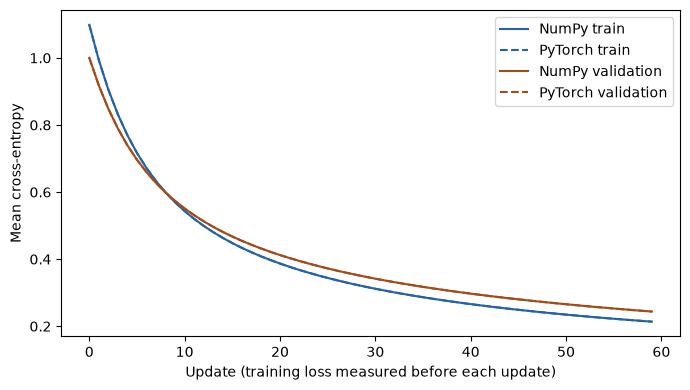

Largest parameter disagreement is checked at every update.
Training loss: 1.0986122886681096 -> 0.2136679721746756


In [17]:
def compare_training(steps=60, lr=0.1):
    W, b = np.zeros((3, 4)), np.zeros(3)
    ref_W, ref_b = W.copy(), b.copy()
    history = {'custom train': [], 'PyTorch train': [], 'custom validation': [], 'PyTorch validation': []}
    for update in range(steps):
        custom = classifier_step(Xtrain, ytrain, W, b, lr)
        reference = torch_reference(Xtrain, ytrain, ref_W, ref_b, lr)
        history['custom train'].append(custom['loss'])
        history['PyTorch train'].append(reference['loss'])
        W, b = custom['W'], custom['b']
        ref_W, ref_b = reference['W'], reference['b']
        history['custom validation'].append(cross_entropy(Tensor(Xval @ W.T + b), yval).value.item())
        with torch.no_grad():
            ref_z = torch.tensor(Xval) @ torch.tensor(ref_W).T + torch.tensor(ref_b)
            history['PyTorch validation'].append(F.cross_entropy(ref_z, torch.tensor(yval)).item())
        close(W, ref_W)
        close(b, ref_b)
    return history, W, b

training_history, final_W, final_b = compare_training()
assert training_history['custom train'][-1] < training_history['custom train'][0]
for split in ('train', 'validation'):
    close(training_history[f'custom {split}'], training_history[f'PyTorch {split}'])
fig, ax = plt.subplots(figsize=(7, 4))
for split, color in [('train', '#2463a6'), ('validation', '#a34b19')]:
    ax.plot(training_history[f'custom {split}'], color=color, label=f'NumPy {split}')
    ax.plot(training_history[f'PyTorch {split}'], '--', color=color, label=f'PyTorch {split}')
ax.set(xlabel='Update (training loss measured before each update)', ylabel='Mean cross-entropy')
ax.legend()
fig.tight_layout()
plt.show()
print('Largest parameter disagreement is checked at every update.')
print('Training loss:', training_history['custom train'][0], '->', training_history['custom train'][-1])

Your engine saves local backward closures, adds contributions along every edge
and schedules each reachable operation once. A forward graph is acyclic even
when the Python program contains a loop: each executed iteration creates new nodes.

PyTorch provides a much larger operation set, devices, dtype support and controls
over graph lifetime. Here arrays are CPU float64, matrix products accept only
rank 1 or 2, and backward produces NumPy arrays that cannot themselves be
differentiated. Reusing our immutable graph with a fresh seed is allowed; it
does not reproduce PyTorch's default release of saved intermediates after backward.

Discuss: why does the bias need a reduction? Why is `u + u` one shared node but
two edges? Why can the correct local rules still give a wrong global gradient?

Instructor discussion: bias entries are reused across the batch, so their
cotangents sum over examples. Node identity preserves shared work; operand
positions preserve its separate contributions. Overwriting those contributions
or processing a node before all its consumers can corrupt backward even with
correct local rules. Agreement here supports this graph and operation set on
the displayed cases, not an unrestricted autodiff implementation.

## Optional: functional gradients

Implement `grad(function)` for a scalar-output function of one `Tensor`.
It should return a callable accepting a numeric array, create a fresh input
leaf, run the function and backward, and return that leaf's cotangent.
No caller-owned `.grad` state exists or is modified. Reject nonscalar outputs.

In [18]:
def grad(function):
    raise NotImplementedError('Optional exercise: functional grad')

In [19]:
def grad(function):
    def evaluate(value):
        x = Tensor(value, name='functional input')
        output = as_tensor(function(x))
        if output.value.shape != ():
            raise ValueError('grad requires a scalar output')
        cotangents = backward(output)
        return cotangents.get(x, np.zeros_like(x.value)).copy()
    return evaluate

In [20]:
original = np.array([1., -2., 3.])
close(grad(lambda x: (x * x).sum())(original), 2 * original)
close(grad(lambda x: Tensor(7.))(original), np.zeros_like(original))
close(original, np.array([1., -2., 3.]))
expect_error(ValueError, lambda: grad(lambda x: x * x)(original))
print('Functional grad checks passed.')

Functional grad checks passed.


## Optional: reconstruct a small Jacobian

Implement `jacobian(function, value)`. Evaluate the function once, then call
backward for each output-coordinate basis seed. Stack the input cotangents
into an array with shape `output.shape + input.shape`. A scalar output needs
one seed; a function independent of its input has zero derivatives.

For vector outputs, each seed selects one row of the usual Jacobian. Why does
this need as many reverse passes as output scalar coordinates? What would
change with forward mode? Use tiny arrays; training needs one scalar-loss seed,
not a materialized Jacobian.

In [21]:
def jacobian(function, value):
    raise NotImplementedError('Optional exercise: Jacobian from basis seeds')

In [22]:
def jacobian(function, value):
    x = Tensor(value)
    output = as_tensor(function(x))
    result = np.zeros((output.value.size,) + x.value.shape)
    for row in range(output.value.size):
        seed = np.zeros_like(output.value)
        seed.reshape(-1)[row] = 1
        result[row] = backward(output, seed).get(x, np.zeros_like(x.value))
    return result.reshape(output.value.shape + x.value.shape)

In [23]:
close(jacobian(lambda x: x * x, np.array([1., 2.])), np.diag([2., 4.]))
close(jacobian(lambda x: (x * x).sum(), np.array([1., 2.])), np.array([2., 4.]))
close(jacobian(lambda x: Tensor([3., 4.]), np.array([1., 2.])), np.zeros((2, 2)))
matrix_input = np.arange(6.).reshape(2, 3)
J = jacobian(lambda x: x * x, matrix_input)
assert J.shape == (2, 3, 2, 3)
close(J.reshape(6, 6), np.diag(2 * matrix_input.reshape(-1)))
print('Jacobian checks passed.')

Jacobian checks passed.


## Optional: JVP and VJP side by side

The supplied example uses $f(x)=A(x\odot x)$ with $A$ shaped $(3,2)$.
An input direction $h\in\mathbb R^2$ gives
$Df(x)[h]=A(2x\odot h)\in\mathbb R^3$.
An output cotangent $v\in\mathbb R^3$ gives
$Df(x)^*[v]=2x\odot(A^\top v)\in\mathbb R^2$.

Predict the two result shapes, then run the supplied comparisons with
`torch.func.jvp` and `torch.func.vjp`. Check the adjoint identity
$\langle v,Df(x)[h]\rangle=\langle Df(x)^*[v],h\rangle$.
This is a worked bridge to forward mode, not a second engine to implement.

In [24]:
A = np.array([[1., 2.], [-2., 1.], [3., -1.]])
point = np.array([1., -2.])
direction = np.array([0.5, 1.])
seed = np.array([1., -1., 2.])
tx = torch.tensor(point)
tA = torch.tensor(A)
function = lambda x: tA @ (x * x)
value_jvp, jvp = torch.func.jvp(function, (tx,), (torch.tensor(direction),))
value_vjp, pullback = torch.func.vjp(function, tx)
vjp, = pullback(torch.tensor(seed))
custom_x = Tensor(point)
custom_y = Tensor(A) @ (custom_x * custom_x)
custom_vjp = backward(custom_y, seed)[custom_x]
analytic_jvp = A @ (2 * point * direction)
close(jvp.numpy(), analytic_jvp)
close(vjp.numpy(), custom_vjp)
close(np.array(seed @ analytic_jvp), np.array(custom_vjp @ direction))
close(value_jvp.numpy(), custom_y.value)
print('JVP:', jvp.numpy(), '| VJP:', custom_vjp)

/private/tmp/autodiff-notebook-review/venv/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


JVP: [-7. -6.  7.] | VJP: [18.  4.]


## Sources

- Simone Scardapane, [original autodiff starter](https://colab.research.google.com/drive/1gJXRw-T2Jj-XrudaQhGHRYbUY_7l0GOG)
  and [original reference fragments](https://colab.research.google.com/drive/1HtjP7WEFLllgFhTE7gGRjdo8e2RV5zNY).
- [Automatic differentiation slides](https://docs.google.com/presentation/d/1RV6QapVTqQkmM1RO2OfYFU6XjqvxdLVSnTPT65gsISQ/edit):
  derivatives as linear maps and reverse mode through adjoints. The terminology
  bridge above is also part of the agreed slide correction checklist.
- Shared [PT01](PT01_Introduction_to_PyTorch.ipynb) and
  [PT02](PT02_Logistic_regression.ipynb): tensor/autograd preparation and classifier setup.
- [JAX Autodiff Cookbook](https://docs.jax.dev/en/latest/notebooks/autodiff_cookbook.html):
  tangent/cotangent terminology and the JVP/VJP distinction. JAX is not a dependency.
- PyTorch [JVP](https://docs.pytorch.org/docs/stable/generated/torch.func.jvp.html)
  and [VJP](https://docs.pytorch.org/docs/stable/generated/torch.func.vjp.html) references.
- Penguins data: Horst, Hill and Gorman (2020),
  [palmerpenguins](https://allisonhorst.github.io/palmerpenguins/), CC0. Original
  collection by Kristen Gorman and Palmer Station LTER. Source URL and SHA-256
  appear in the data cell. Only rows missing the selected measurements are removed.